## Text Generation using Gated Recurrent Unit Networks - ML


Gated Recurrent Unit (GRU) networks are a type of recurrent neural network designed to handle sequential data while reducing the complexity of traditional RNNs. GRUs are a simplified advancement of LSTM, where they merge multiple gates into update and reset gates, hence learning long-term dependencies with faster training and fewer parameters.

* Simplified alternative to LSTM
* Handles sequence and time‑series data effectively
* Widely used in NLP, speech and forecasting tasks

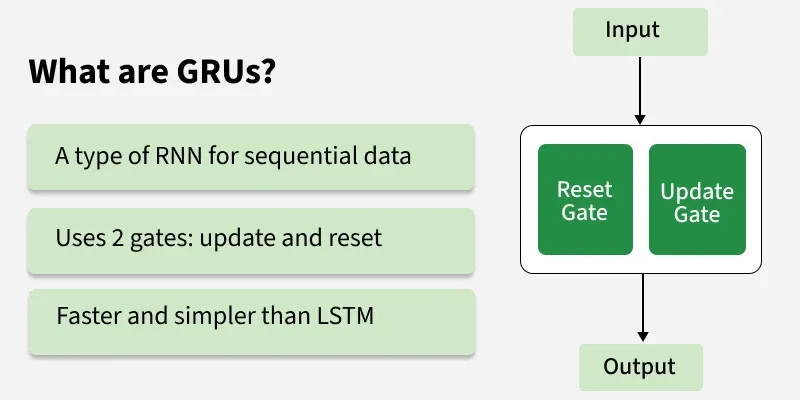

### What are Gated Recurrent Units (GRU)?

GRUs consist of two main gates: the **update gate** and the **reset gate**. The update gate controls how much of the past information to carry forward, while the reset gate determines how much of the past information to forget. This architecture allows GRUs to capture long-term dependencies in sequential data without the complexity of LSTMs.

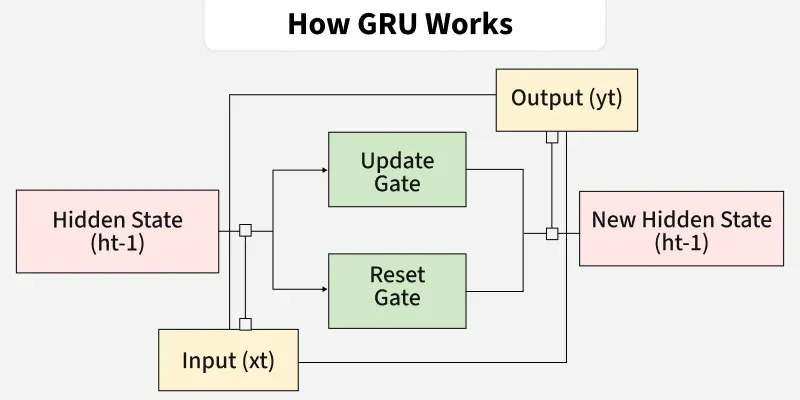

Gated Recurrent Units (GRUs) are a type of RNN introduced by Cho et al. in 2014. The core idea behind GRUs is to use gating mechanisms to selectively update the hidden state at each time step allowing them to remember important information while discarding irrelevant details. GRUs aim to simplify the LSTM architecture by merging some of its components and focusing on just two main gates: the update gate and the reset gate.

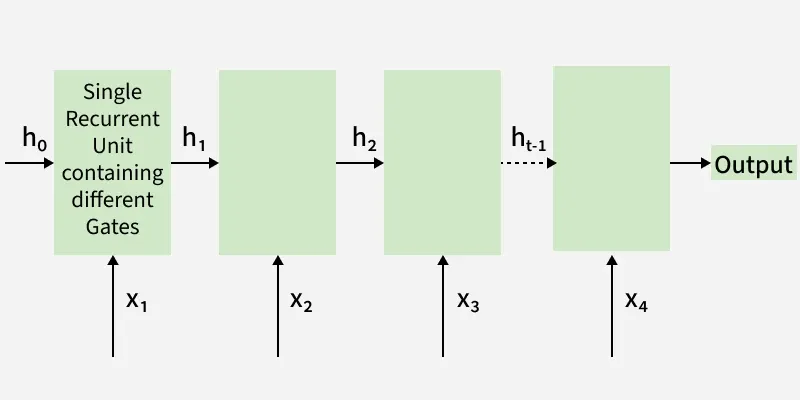

The GRU consists of two main gates:

* **Update Gate (zt​):** This gate decides how much information from previous hidden state should be retained for the next time step.
* **Reset Gate (rt​):** This gate determines how much of the past hidden state should be forgotten.

These gates allow GRU to control the flow of information in a more efficient manner compared to traditional RNNs which solely rely on hidden state.

## Equations for GRU Operations

#### 1. Reset Gate (rt​):
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$

#### 2. Update Gate (zt​):
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$

#### 3. Candidate Activation (h~t​):
$$\tilde{h}_t = \tanh(W \cdot [r_t * h_{t-1}, x_t])$$

#### 4. Final Hidden State (ht​):
$$h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t$$

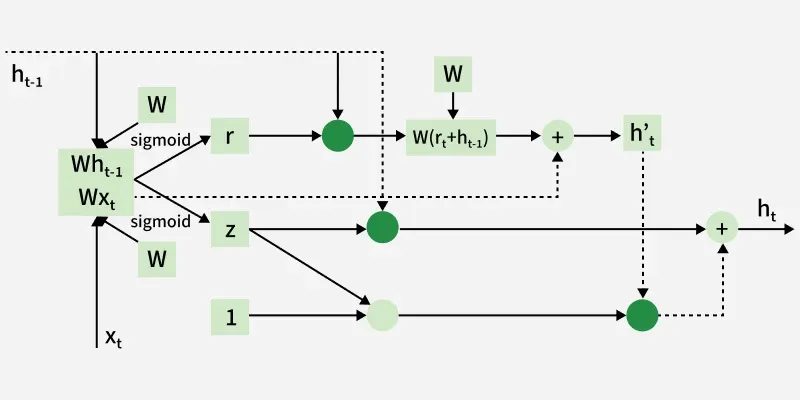

### Handling the Vanishing Gradient Problem

* GRUs use gating mechanisms to regulate the flow of information and gradients during training
* These gates help preserve important information over long sequences
* They prevent gradients from shrinking too much, enabling better learning of long-term dependencies





## Implementation

Now let's implement simple GRU model in Python using Keras. We'll start by preparing the necessary libraries and dataset.

### 1. Importing Libraries

We will import the necessary libraries for implementing our GRU model such as numpy, pandas, MinMaxScaler, TensorFlow and Adam.

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam

### 2. Loading the Dataset



In [14]:

df = pd.read_csv('data.csv', parse_dates=['Date'], index_col='Date')


In [15]:
df.head(3)

,Temperature
Date,
2010-01-01,27.483571
2010-01-02,24.308678
2010-01-03,28.238443


### 3. Preprocessing the Data

We will scale our data to ensure all features have equal weight and avoid any bias. In this example, we will use MinMaxScaler, which scales the data to a range between 0 and 1. Proper scaling is important because neural networks tend to perform better when input features are normalized.

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

In [17]:
scaled_data

array([[0.5496123 ],
       [0.46622273],
       [0.56943925],
       ...,
       [0.37470644],
       [0.70145198],
       [0.757248  ]], shape=(8000, 1))

### 4. Preparing Data for GRU

We will define a function to prepare our data for training our model.

In [18]:
def create_dataset(data, time_step=1):
    X, y = [],[]

    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 100
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

## 5. Building the GRU Model

In [19]:
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(GRU(units=50))
model.add(Dense(1))
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model.summary()

c:\Users\PANDIT JI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 100, 50)        │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

### 6. Training the Model

model.fit() trains the model on the prepared dataset. The epochs=10 specifies the number of iterations over the entire dataset, and batch_size=32 defines the number of samples per batch.

In [20]:
model.fit(X, y, epochs=10, batch_size=32)

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 0.0409
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - loss: 0.0181
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - loss: 0.0176
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - loss: 0.0179
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - loss: 0.0179
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - loss: 0.0177
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 45s 109ms/step - loss: 0.0183
Epoch 8/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - loss: 0.0179
Epoch 9/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - loss: 0.0177
Epoch 10/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - loss: 0.0173


### 7. Making Predictions

In [21]:
input_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)
predicted_values = model.predict(input_sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step


### 8. Inverse Transforming the Predictions

Inverse Transforming the Predictions refers to the process of converting the scaled (normalized) predictions back to their original scale.

In [22]:
predicted_values = scaler.inverse_transform(predicted_values)
print(
    f"The predicted temperature for the next day is: {predicted_values[0][0]:.2f}°C")

The predicted temperature for the next day is: 23.71°C
